In [30]:
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn import model_selection
from sklearn import neighbors
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
diabetes = datasets.load_diabetes()
tts = model_selection.train_test_split(diabetes.data, diabetes.target, test_size=0.25)
(diabetes_train_features, diabetes_test_features, diabetes_train_target, diabetes_test_target) = tts

In [4]:
diabetes_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
diabetes_df['target'] = diabetes.target
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


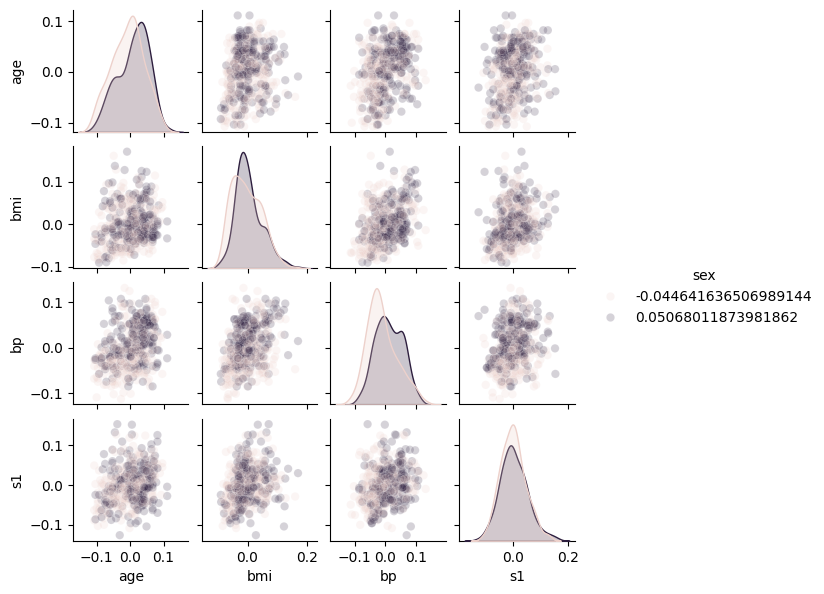

In [8]:
sns.pairplot(diabetes_df[["age", "sex", "bmi", "bp", "s1"]], height=1.5, hue="sex", plot_kws={'alpha': 0.2})

### Srednje vrijednosti
Srednje vrijednosti koje ćemo koristiti su artimetička sredina i median.

In [10]:
podaci = np.array([1, 3, 5, 8, 11, 13, 15])
print(np.mean(podaci), np.median(podaci))

8.0 8.0


In [15]:
podaci_anomaly = np.array([1, 3, 5, 8, 11, 13, 40])
print(np.mean(podaci_anomaly), np.median(podaci_anomaly))

11.571428571428571 8.0


### kNN sa srednjim vrijednostima

In [17]:
udaljenosti = np.array([2.0, 4.0, 4.0])
blizina = 1.0 / udaljenosti
tezina = blizina / np.sum(blizina)
cijene = np.array([180000, 200000, 220000])
mean = np.mean(cijene)
tezina_mean = np.dot(cijene, tezina)
print(mean)
print(tezina_mean)

200000.0
195000.0


#### KNN Regresor

In [33]:
diabetes = datasets.load_diabetes()
tts = model_selection.train_test_split(diabetes.data, diabetes.target, test_size=0.25)
(diabetes_train_features, diabetes_test_features, diabetes_train_target, diabetes_test_target) = tts

knn = neighbors.KNeighborsRegressor(n_neighbors=3)
model = knn.fit(diabetes_train_features, diabetes_train_target)
predictions = model.predict(diabetes_test_features)
metrics.mean_squared_error(diabetes_test_target, predictions)

3885.1191191191187